In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

sns.set_theme(style="whitegrid")

In [2]:
X_train = pd.read_csv('../data/processed/X_train_scaled.csv')
X_test = pd.read_csv('../data/processed/X_test_scaled.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

In [3]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
}

In [4]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "Predictions": y_pred,
        "Probabilities": y_proba,
        "Model": model
    }
    
    print(f"{name} -> ROC-AUC: {results[name]['ROC-AUC']:.4f} | F1: {results[name]['F1 Score']:.4f}")

Logistic Regression -> ROC-AUC: 0.8086 | F1: 0.8446
Decision Tree -> ROC-AUC: 0.6781 | F1: 0.7597
Random Forest -> ROC-AUC: 0.8256 | F1: 0.8581


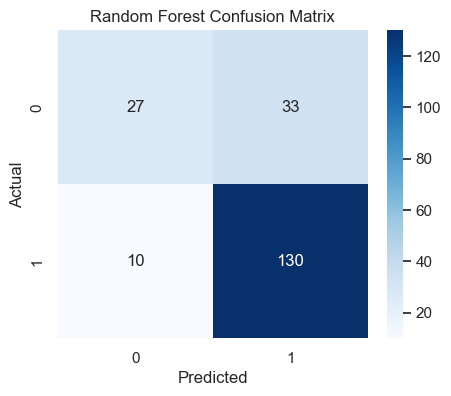

In [5]:
rf_preds = results['Random Forest']['Predictions']
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('../images/confusion_matrix.png')
plt.show()

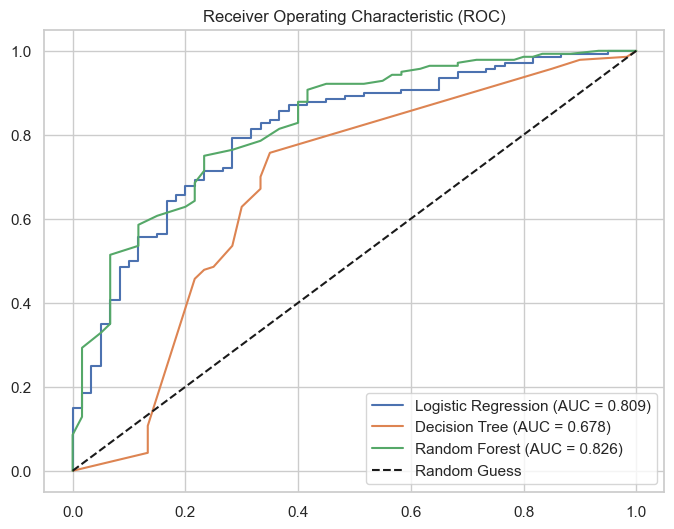

In [6]:
plt.figure(figsize=(8, 6))
for name, metrics in results.items():
    fpr, tpr, _ = roc_curve(y_test, metrics['Probabilities'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {metrics['ROC-AUC']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.savefig('../images/roc_curve.png')
plt.show()

/var/folders/sj/769vt5hs1y3c1xnmcfjtmfl40000gn/T/ipykernel_97043/2866618009.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X_train.columns[indices], palette="viridis")


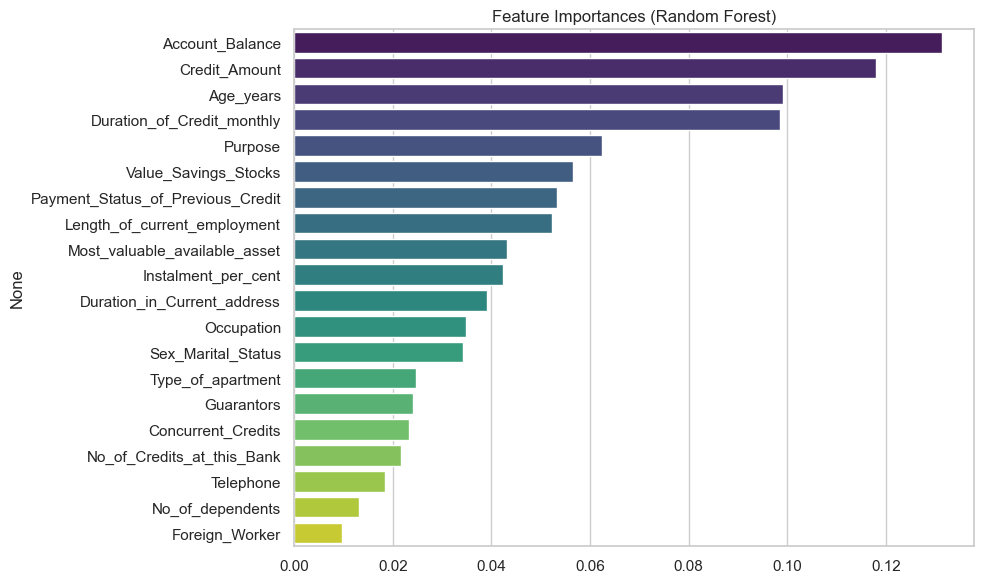

In [7]:
rf_model = results['Random Forest']['Model']
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=X_train.columns[indices], palette="viridis")
plt.title('Feature Importances (Random Forest)')
plt.tight_layout()
plt.savefig('../images/feature_importance.png')
plt.show()

In [8]:
joblib.dump(rf_model, '../models/credit_model.pkl')
print("Champion Model saved to ../models/credit_model.pkl")

Champion Model saved to ../models/credit_model.pkl
